In [1]:
# Instalando bibliotecas necessárias, como o qiskit

!pip install qiskit==1.2.4 qiskit-aer==0.15.1 qiskit[visualization] --quiet
print ("Instalação concluída com sucesso!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.0 MB/s eta 0:00:00
Instalação concluída com sucesso!


In [2]:
# Importando bibliotecas necessárias, como numpy, qiskit, sklearn (para a rede neural clássica) e matplotlib para visualização de gráficos

import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister # Ferramentas do qiskit para a rede neural quântica
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Estimator as AerEstimator
from qiskit.quantum_info import SparsePauliOp

from sklearn.neural_network import MLPClassifier # Ferramentas para a rede neural clássica
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt # Gráficos
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

SEED = 42 # Semente dos dados
np.random.seed(SEED)

Dataset total: 1000 pontos
Dataset de treino: 800 pontos
Dataset de validação: 100 pontos
Dataset de teste: 100 pontos


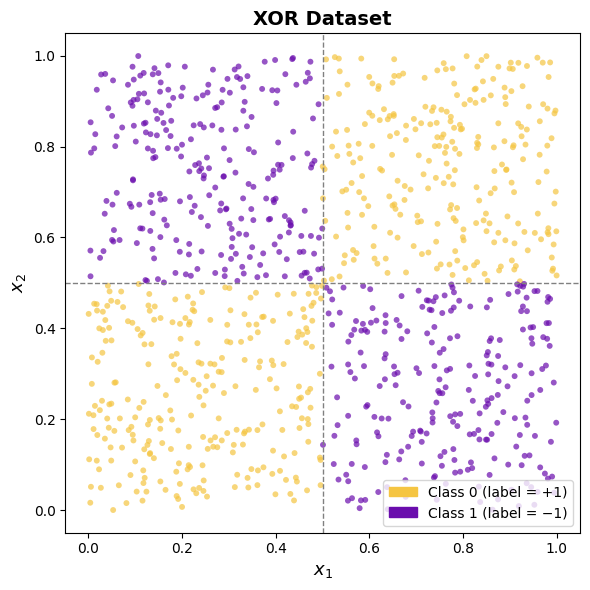

In [4]:
def dataset_xor(n_amostras=1000, seed=SEED): # Definção do dataset a ser utilizado
  rng = np.random.default_rng(seed) # Geração de pontos aleatórios
  pontos = []

  while len(pontos) < n_amostras: # Aqui os pontos são gerados aleatoriamente entre 0 e 1, e os pontos na fronteira são descartados
    x1, x2 = rng.uniform(0, 1, size=2)
    if x1==0.5 or x2==0.5:
      continue
    pontos.append((x1, x2))
  X = np.array(pontos)
  y_classes = ((X[:, 0] > 0.5) ^ (X[:, 1] > 0.5)).astype(int) # Validação do portão XOR
  y_labels = np.where(y_classes == 0, 1.0, -1.0) # Transformação dos números binários em spin + e -, mais compatível com as operações quânticas a serem realizadas

  return X, y_labels, y_classes

def split(X, y_labels, y_classes): # Split do dataset em 80/10/10, diferente do artigo que usa 750/63/187 de maneira meio arbitrária
  idx = np.random.permutation(len(X))
  X, y_labels, y_classes = X[idx], y_labels[idx], y_classes[idx]

  n = len(X) # Essas linhas garantem o corte exato sempre, não importando o tamanho do dataset
  corte1 = int(0.8 * n)
  corte2 = int(0.9 * n)

  X_train, y_train_lbl, y_train_cls = X[:corte1],       y_labels[:corte1],       y_classes[:corte1] # lbl são os dados para o modelo quântico e cls para o clássico
  X_val,   y_val_lbl,   y_val_cls   = X[corte1:corte2], y_labels[corte1:corte2], y_classes[corte1:corte2]
  X_test,  y_test_lbl,  y_test_cls  = X[corte2:],       y_labels[corte2:],       y_classes[corte2:]

  return (X_train, y_train_lbl, y_train_cls,
          X_val,   y_val_lbl,   y_val_cls,
          X_test,  y_test_lbl,  y_test_cls)

X, y_labels, y_classes = dataset_xor() # Gera e divide a base de dados pra ser usada
(
      X_train, y_train_lbl, y_train_cls,
      X_val,   y_val_lbl,   y_val_cls,
      X_test,  y_test_lbl,  y_test_cls
) = split(X, y_labels, y_classes)

print(f"Dataset total: {len(X)} pontos")
print(f"Dataset de treino: {len(X_train)} pontos")
print(f"Dataset de validação: {len(X_val)} pontos")
print(f"Dataset de teste: {len(X_test)} pontos")

cores = ['#F5C542', '#6A0DAD']
cmap = ListedColormap(cores)
fig, ax = plt.subplots(figsize=(6,6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y_classes, cmap=cmap, s=18, alpha=0.7, edgecolors='none')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('XOR Dataset', fontsize=14, fontweight='bold')
patch0 = mpatches.Patch(color=cores[0], label='Class 0 (label = +1)')
patch1 = mpatches.Patch(color=cores[1], label='Class 1 (label = −1)')
ax.legend(handles=[patch0, patch1], fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
def circuito_q(theta0, alpha0, theta1, alpha1, x1, x2): # Circuito com 1 qubit assim como o de de Grossu (2021)

    qc = QuantumCircuit(1, 1) # Criação de 1 qubit e 1 bit clássico

    qc.h(0)                          # Superposição uniforme via Haddamard
    qc.rz(theta0*x1 + alpha0, 0)     # x1 é codificado nos ângulos theta0 e alpha0
    qc.rx(theta1*x2 + alpha1, 0)     # x2 é codificado nos ângulos theta1 e alpha1
    qc.measure(0, 0) # Mede o qubit e armazena seus dados no bit

    return qc

In [6]:
SIMULATOR = AerSimulator() # Simula o computador quântico
N_SHOTS = 1024 # Número de execuções por avaliação do circuito

def valor_expectativa(params, x1, x2):
  theta0, theta1, alpha0, alpha1 = params
  qc = circuito_q(theta0, theta1, alpha0, alpha1, x1, x2) # Constrói o circuito com os parâmetros atuais
  job = SIMULATOR.run(qc, shots=N_SHOTS) # Executa o circuito N_SHOTS vezes e retorna um dicionário de quantas vezes cada resultado apareceu
  contagens = job.result().get_counts()
  contagem_0 = contagens.get('0', 0)
  contagem_1 = contagens.get('1', 0) # Extrai as contagens dos resultados
  expectativa = (contagem_0 - contagem_1)/N_SHOTS # Calcula o valor esperado <Z>

  return expectativa

def loss_mse(params, X_batch, y_batch): # Desempacota cada linha de X_batch
  total =0.0

  for (x1, x2), y in zip(X_batch, y_batch):
    pred = valor_expectativa(params, x1, x2)
    total += (y - pred)**2 # Acúmulo de erro quadrático em cada ponto

  return total / len(X_batch) # Obtém a média do erro

def gradiente_parameter_shift(params, X_batch, y_batch):
  shift = np.pi/2
  a = 0.5 # Parâmetro de shift para portões do tipo Pauli como usados no circuito
  grads = np.zeros(len(params))

  for j in range(len(params)): # Para cada parâmetro em theta cria uma cópia do vetor e desloca apenas esse parâmetro para cima em pi/2
    params_up = params.copy()
    params_up[j] = params[j] + shift
    loss_up = loss_mse(params_up, X_batch, y_batch) # Calcula a perda com o vetor já deslocado

    params_down = params.copy()
    params_down[j] = params[j] - shift
    loss_down = loss_mse(params_down, X_batch, y_batch)

    grads[j] = a*(loss_up - loss_down) # O gradiente é corrigido e está pronto para ser recalculado com um novo shift

  return grads

def classificar(expectativa): # Classifica o qubit, aplicando o equivalente ao portão XOR
  return 0 if expectativa >= 0 else 1

In [9]:
LEARNING_RATE = 0.01 # Intervalo de tempo
BATCH_SIZE = 25 # Número de pontos usados para estimar o gradiente de uma vez
N_EPOCHS = 15 # Número de vezes que o algoritmo passa pelo dataset inteiro

params_q = np.random.uniform(0, 2*np.pi, size=4) # Inicia os parâmetros em posições aleatórias
print(f"Parâmetros iniciais: {np.round(params_q, 4)}")
print(f"\nIniciando treinamento: {N_EPOCHS} épocas, batch={BATCH_SIZE}, lr={LEARNING_RATE}")
print("─" * 60)

historico_loss_q = []
historico_acc_val_q = []
historico_params_q = []
batch_global = 0

for epoca in range(N_EPOCHS): # Embaralhamento dos dados a cada época de treinamento

  idx_treino = np.random.permutation(len(X_train))
  X_shuf = X_train[idx_treino]
  y_shuf = y_train_lbl[idx_treino]
  n_batches = len(X_shuf) // BATCH_SIZE # Calcula o número de batches no dataset, com 25 pontos cada, e 32 batches por época

  for b in range(n_batches):
    inicio = b*BATCH_SIZE # Inicializa os batches, recortando seus 25 pontos do dataset embaralhado
    fim = inicio + BATCH_SIZE
    X_batch = X_shuf[inicio:fim]
    y_batch = y_shuf[inicio:fim]

    loss_batch = loss_mse(params_q, X_batch, y_batch) # Calcula o erro médio nos 25 pontos do batch com os parâmetros atuais
    historico_loss_q.append(loss_batch)
    grads = gradiente_parameter_shift(params_q, X_batch, y_batch) # Calcula o gradiente de todos os 4 parâmetros via shift
    params_q = params_q - LEARNING_RATE*grads # Atualiza os parâmetros na direção oposta ao gradiente, diminuindo a energia do sistema
    historico_params_q.append(params_q.copy()) # Grava os valores atuais dos parâmetros

    if batch_global % 50 == 0: # Avalia o modelo no conjunto de validação a cada 50 batches (computacionalmente caro)
      preds_val = [classificar(valor_expectativa(params_q, x1, x2)) for x1, x2 in X_val] # Roda o circuito em cada ponto de validação e compara com os rótulos verdadeiros para calcular a porcentagem de acertos
      acc_val = accuracy_score(y_val_cls, preds_val)
      historico_acc_val_q.append((batch_global, acc_val))
      print(f"Época {epoca+1:3d}/{N_EPOCHS} | "f"Batch {batch_global:4d} | "f"Loss: {loss_batch:.4f} | "f"Acc Val: {acc_val:.2%}")

    batch_global += 1 # Incrementa o contador de batches para o loop prosseguir

print("─" * 60)
print(f"\nTreinamento concluído.")
print(f"Parâmetros finais: {np.round(params_q, 5)}")
print(f"  θ₀ = {params_q[0]:.5f}  (ref. artigo: π ≈ 3.14159)")
print(f"  θ₁ = {params_q[1]:.5f}  (ref. artigo: π ≈ 3.14159)")
print(f"  α₀ = {params_q[2]:.5f}  (ref. artigo: -π/2 ≈ -1.5708 ou +3π/2 ≈ 4.7124)")
print(f"  α₁ = {params_q[3]:.5f}  (ref. artigo: -π/2 ≈ -1.5708 ou +3π/2 ≈ 4.7124)")

Parâmetros iniciais: [2.0942 3.0909 3.5988 1.4975]

Iniciando treinamento: 15 épocas, batch=25, lr=0.01
────────────────────────────────────────────────────────────
Época   1/15 | Batch    0 | Loss: 0.9862 | Acc Val: 51.00%
Época   2/15 | Batch   50 | Loss: 0.6496 | Acc Val: 69.00%
Época   4/15 | Batch  100 | Loss: 0.5805 | Acc Val: 78.00%
Época   5/15 | Batch  150 | Loss: 0.4972 | Acc Val: 86.00%
Época   7/15 | Batch  200 | Loss: 0.5220 | Acc Val: 88.00%
Época   8/15 | Batch  250 | Loss: 0.5066 | Acc Val: 93.00%
Época  10/15 | Batch  300 | Loss: 0.5216 | Acc Val: 96.00%
Época  11/15 | Batch  350 | Loss: 0.4885 | Acc Val: 92.00%
Época  13/15 | Batch  400 | Loss: 0.6146 | Acc Val: 94.00%
Época  15/15 | Batch  450 | Loss: 0.4713 | Acc Val: 97.00%
────────────────────────────────────────────────────────────

Treinamento concluído.
Parâmetros finais: [2.44068 2.00219 3.7758  1.24476]
  θ₀ = 2.44068  (ref. artigo: π ≈ 3.14159)
  θ₁ = 2.00219  (ref. artigo: π ≈ 3.14159)
  α₀ = 3.77580  (ref.

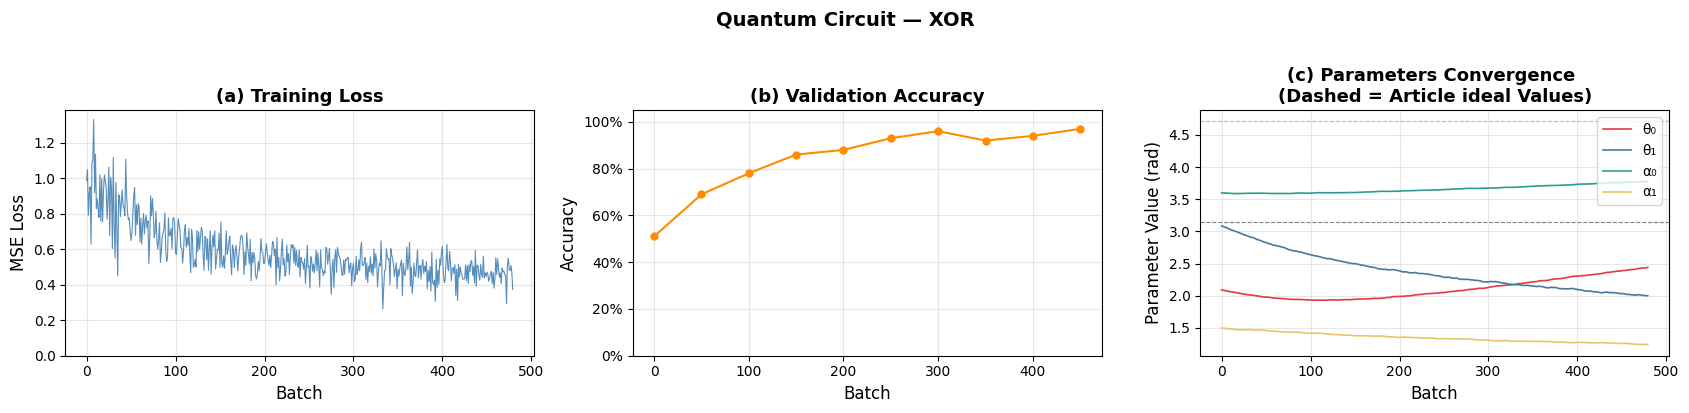

In [12]:
params_hist = np.array(historico_params_q)
batches_val, accs_val = zip(*historico_acc_val_q)
fig, axes = plt.subplots(1, 3, figsize=(17,4))

axes[0].plot(historico_loss_q, color='steelblue', linewidth=0.8, alpha=0.9) # Gráfico para avaliação das perdas durante o treinamento
axes[0].set_xlabel('Batch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('(a) Training Loss', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, None)
axes[0].grid(alpha=0.3)

axes[1].plot(batches_val, accs_val, 'o-', color='darkorange', linewidth=1.5, markersize=5) # Gráfico para avaliação da acurácia do resultado
axes[1].set_xlabel('Batch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('(b) Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].grid(alpha=0.3)

cores_params  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
nomes_params  = ['θ₀', 'θ₁', 'α₀', 'α₁']
refs_params   = [np.pi, np.pi, 3*np.pi/2, 3*np.pi/2] # Comparação com os parâmetros do artigo

for i in range(4):
    axes[2].plot(params_hist[:, i], color=cores_params[i], linewidth=1.2, label=nomes_params[i])
    axes[2].axhline(refs_params[i], color=cores_params[i], linestyle='--', linewidth=0.8, alpha=0.6)

axes[2].set_xlabel('Batch', fontsize=12) # Gráfico de convergência dos parâmetros, note que eles não necessariamente convergiram, talvez seja necessário um número de dados maior
axes[2].set_ylabel('Parameter Value (rad)', fontsize=12)
axes[2].set_title('(c) Parameters Convergence \n(Dashed = Article ideal Values)', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.suptitle('Quantum Circuit — XOR', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
print("Avaliando no conjunto de teste quântico...")

preds_q  = [classificar(valor_expectativa(params_q, x1, x2)) for x1, x2 in X_test]
acc_q    = accuracy_score(y_test_cls, preds_q) # Comparação para validação da precisão do teste

print(f"\n{'='*50}")
print(f"  Acurácia no Teste (Quântico): {acc_q:.2%}")
print(f"{'='*50}")
print("\nRelatório de Classificação:")
print(classification_report(y_test_cls, preds_q, target_names=['Classe 0', 'Classe 1']))

Avaliando no conjunto de teste quântico...

  Acurácia no Teste (Quântico): 95.00%

Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 0       0.94      0.96      0.95        51
    Classe 1       0.96      0.94      0.95        49

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



  Acurácia no Teste (MLP Clássico): 85.00%
  Nº de parâmetros MLP             : 25
  Nº de parâmetros Quântico        : 4

Relatório de Classificação (MLP):
              precision    recall  f1-score   support

    Classe 0       0.81      0.92      0.86        51
    Classe 1       0.90      0.78      0.84        49

    accuracy                           0.85       100
   macro avg       0.86      0.85      0.85       100
weighted avg       0.86      0.85      0.85       100



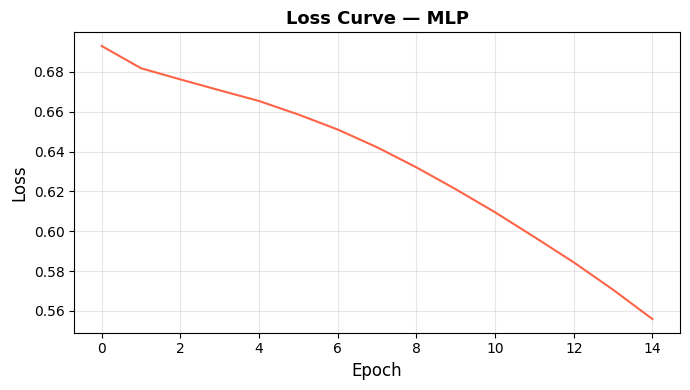

In [33]:
scaler = MinMaxScaler() # Normalização dos dados
X_tr_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_te_sc = scaler.transform(X_test)

mlp = MLPClassifier( # Definição do modelo
    hidden_layer_sizes = (6,), # 1 camada oculta com 6 neurônios (dá pra ir mudando isso), o modelo quântico usa o mesmo número de parâmetros do que 4 neurônios ocultos usariam aqui
    activation = 'relu', # Função de ativação ReLu: f(x)=max(0,x), introduzindo linearidade no problema
    solver = 'sgd', # Otimizador Stochastic Gradient Descent, que é equivalente ao método usado no modelo quântico
    learning_rate_init = 0.01, # Taxa de aprendizado
    batch_size = 25, # Número de amostras por atualização dos pesos
    max_iter = 15, # Número máximo de épocas de treinamento (deixar os mesmos que o modelo quântico para uma comparação justa)
    random_state = SEED, # Semente para reprodutibilidade
    early_stopping = False, # Não para o treino antes
    verbose = False # Não imprime o progresso do treino
)

mlp.fit(X_tr_sc, y_train_cls) # Treina o modelo definido anteriormente em cima dos dados normalizados
preds_mlp = mlp.predict(X_te_sc) # Gera predições no conjunto de teste
acc_mlp = accuracy_score(y_test_cls, preds_mlp) # Calcula a acurácia
n_params_mlp = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

print(f"{'='*50}")
print(f"  Acurácia no Teste (MLP Clássico): {acc_mlp:.2%}")
print(f"  Nº de parâmetros MLP             : {n_params_mlp}")
print(f"  Nº de parâmetros Quântico        : 4")
print(f"{'='*50}")
print("\nRelatório de Classificação (MLP):")
print(classification_report(y_test_cls, preds_mlp, target_names=['Classe 0', 'Classe 1']))

fig, ax = plt.subplots(figsize=(7, 4)) # Gera o gráfico de loss por época
ax.plot(mlp.loss_curve_, color='tomato', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Loss Curve — MLP', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

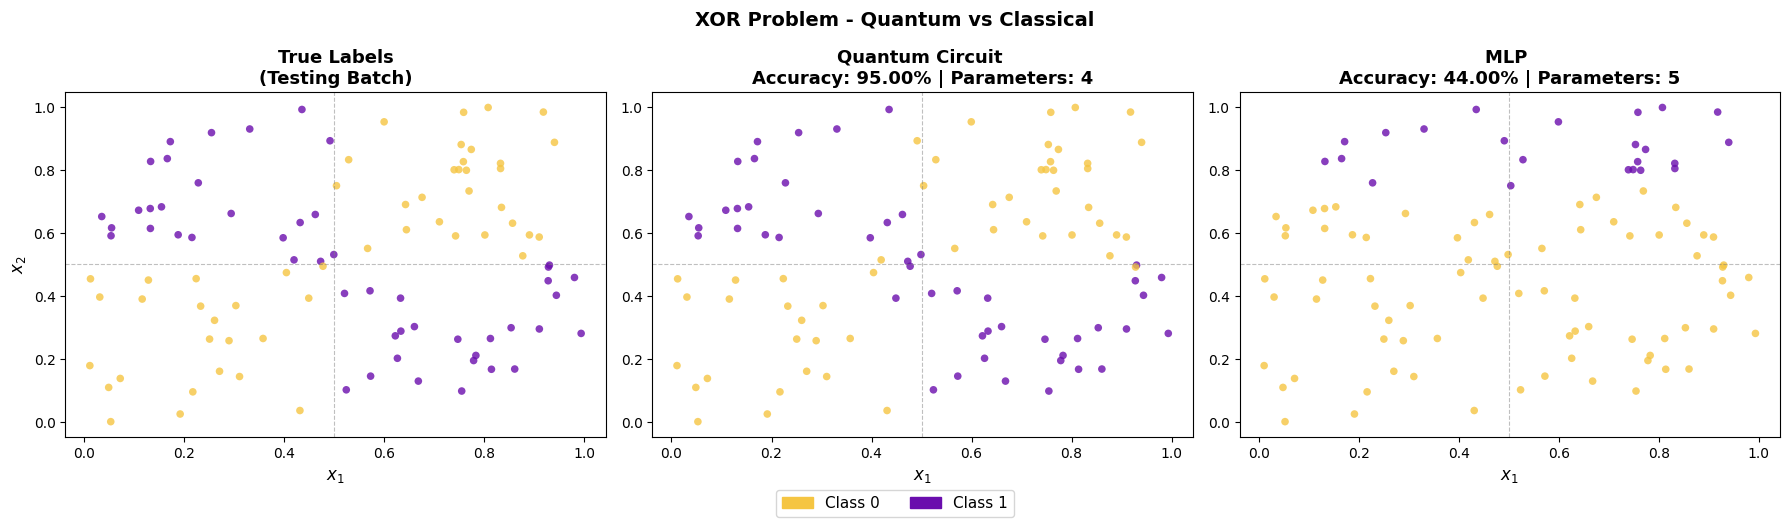


═══════════════════════════════════════════════════════
  RESUMO COMPARATIVO
═══════════════════════════════════════════════════════
  Métrica                          Quântico        MLP
  ---------------------------------------------------
  Acurácia no Teste                  95.00%     44.00%
  Nº de Parâmetros                        4          5
  Epochs/Iterações                      150        150
  Batch Size                             25         25
  Learning Rate                       0.025      0.025
═══════════════════════════════════════════════════════


In [18]:
cmap_bicolor = ListedColormap(['#F5C542', '#6A0DAD'])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test_cls, cmap=cmap_bicolor, s=30, edgecolors='none', alpha=0.8)
axes[0].set_title('True Labels\n(Testing Batch)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('$x_1$', fontsize=12)
axes[0].set_ylabel('$x_2$', fontsize=12)
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[1].scatter(X_test[:, 0], X_test[:, 1], c=preds_q, cmap=cmap_bicolor, s=30, edgecolors='none', alpha=0.8)
axes[1].set_title(f'Quantum Circuit \nAccuracy: {acc_q:.2%} | Parameters: 4', fontsize=13, fontweight='bold')
axes[1].set_xlabel('$x_1$', fontsize=12)
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[2].scatter(X_test[:, 0], X_test[:, 1], c=preds_mlp, cmap=cmap_bicolor, s=30, edgecolors='none', alpha=0.8)
axes[2].set_title(f'MLP \nAccuracy: {acc_mlp:.2%} | Parameters: {n_params_mlp}', fontsize=13, fontweight='bold')
axes[2].set_xlabel('$x_1$', fontsize=12)
axes[2].axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

patch0 = mpatches.Patch(color='#F5C542', label='Class 0')
patch1 = mpatches.Patch(color='#6A0DAD', label='Class 1')
fig.legend(handles=[patch0, patch1], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('XOR Problem - Quantum vs Classical', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "═" * 55)
print("  RESUMO COMPARATIVO")
print("═" * 55)
print(f"  {'Métrica':<30} {'Quântico':>10} {'MLP':>10}")
print("  " + "-" * 51)
print(f"  {'Acurácia no Teste':<30} {acc_q:>10.2%} {acc_mlp:>10.2%}")
print(f"  {'Nº de Parâmetros':<30} {'4':>10} {str(n_params_mlp):>10}")
print(f"  {'Epochs/Iterações':<30} {'150':>10} {'150':>10}")
print(f"  {'Batch Size':<30} {'25':>10} {'25':>10}")
print(f"  {'Learning Rate':<30} {'0.025':>10} {'0.025':>10}")
print("═" * 55)

Calculando fronteira quântica (900 pontos)...
Calculando fronteira clássica...


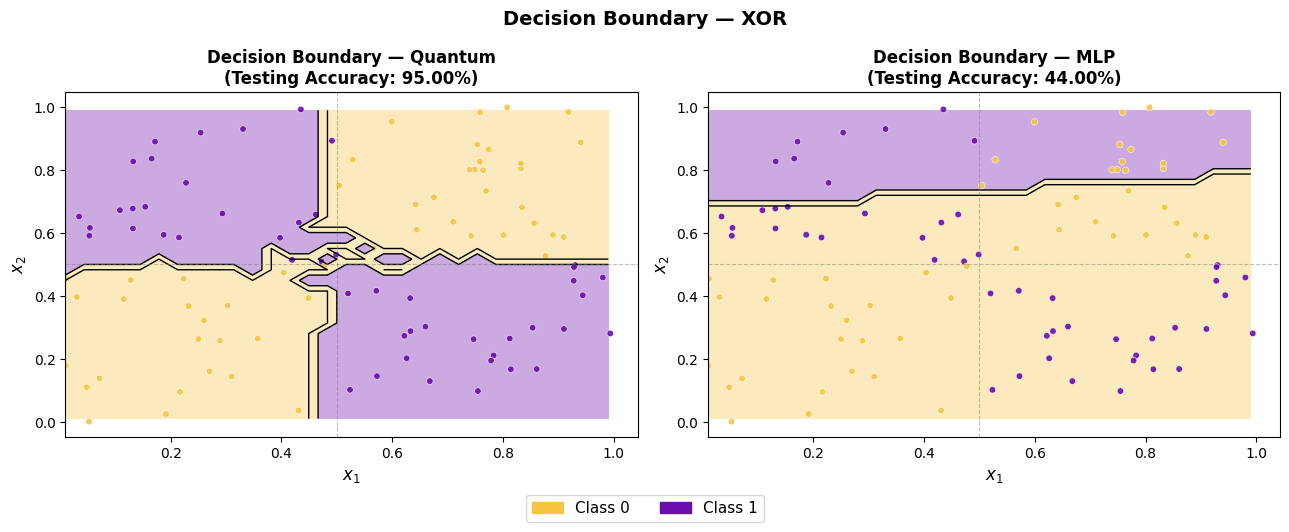

In [19]:
RESOLUCAO = 30
xs = np.linspace(0.01, 0.99, RESOLUCAO)
grade_x1, grade_x2 = np.meshgrid(xs, xs)
grade_pontos = np.c_[grade_x1.ravel(), grade_x2.ravel()]

print(f"Calculando fronteira quântica ({RESOLUCAO**2} pontos)...")
preds_grade_q = np.array([
    classificar(valor_expectativa(params_q, x1, x2))
    for x1, x2 in grade_pontos
]).reshape(RESOLUCAO, RESOLUCAO)

print("Calculando fronteira clássica...")
preds_grade_mlp = mlp.predict(
    scaler.transform(grade_pontos)
).reshape(RESOLUCAO, RESOLUCAO)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
titulos   = [
    f'Decision Boundary — Quantum\n(Testing Accuracy: {acc_q:.2%})',
    f'Decision Boundary — MLP\n(Testing Accuracy: {acc_mlp:.2%})'
]
grades    = [preds_grade_q, preds_grade_mlp]

for ax, grade, titulo in zip(axes, grades, titulos):
    ax.contourf(grade_x1, grade_x2, grade,
                alpha=0.35, cmap=cmap_bicolor, levels=1)
    ax.contour(grade_x1, grade_x2, grade,
               colors='black', linewidths=1.0, levels=1)
    ax.scatter(X_test[:, 0], X_test[:, 1],
               c=y_test_cls, cmap=cmap_bicolor,
               s=22, edgecolors='white', linewidths=0.4, alpha=0.9)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(titulo, fontsize=12, fontweight='bold')

fig.legend(handles=[patch0, patch1], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Decision Boundary — XOR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()